# Proyecto Integrador Módulo 4, Avance 1
## Predicción de Fuga de Clientes (Churn), FinanceGuard


## Contexto del Proyecto

FinanceGuard es un banco digital que ha crecido hasta alcanzar diez mil clientes activos. La
dirección detectó un problema crítico: una tasa de abandono de clientes (churn) del 20% anual, que se traduce en pérdidas millonarias. La meta es reducir ese churn al 15%.

### Qué es el churn bancario

El churn, o tasa de abandono, es el porcentaje de clientes que dejan de usar los servicios del
banco en un período determinado. Es uno de los indicadores más vigilados en la industria
financiera, por varias razones. Conseguir un cliente nuevo cuesta bastante más que retener uno
existente. Los clientes de largo plazo generan más ingresos a lo largo del tiempo. Y una tasa
de abandono alta suele ser señal de problemas de servicio. En la era digital, además, cambiar
de banco es cada vez más fácil, lo que agrava el riesgo.

### Objetivo del Avance 1

Desarrollar un modelo de regresión logística que sirva como línea base (baseline) para el
proyecto. El modelo debe predecir qué clientes tienen mayor probabilidad de abandonar,
identificar los factores más influyentes en esa decisión, y permitir al equipo de retención
actuar de forma anticipada. Los modelos más complejos de los avances siguientes se compararán
contra este baseline.

## Qué es la Regresión Logística

Aunque su nombre incluye la palabra regresión, en realidad es un algoritmo de clasificación que predice la probabilidad de que algo ocurra, un valor entre 0 y 1. En este caso, la probabilidad
de que un cliente abandone.

**La función sigmoide:** Es el corazón del modelo. Toma la combinación de las variables (que
puede ser cualquier número) y la transforma en una probabilidad entre 0 y 1. Su fórmula es
sigma de z igual a 1 sobre 1 más e elevado a menos z. Si el resultado supera 0,5, el modelo
predice abandono.

**Los odds:** Son la razón entre la probabilidad de que algo ocurra y la de que no ocurra. Si
la probabilidad de churn es 0,75, los odds son 3, es decir, es tres veces más probable que
abandone a que no lo haga.

**El odds ratio:** Mide cuánto cambian los odds cuando una variable aumenta en una unidad. Se
calcula como e elevado al coeficiente. Es la forma más directa de interpretar el impacto de
cada variable: mayor a 1 aumenta el riesgo de churn, menor a 1 lo reduce.

**Los coeficientes:** Cada variable tiene uno. Positivo significa que aumenta la probabilidad
de churn, negativo que la reduce, y su magnitud indica la fuerza del efecto.

## 1. Importación de Librerías

In [2]:
# Manipulacion de datos
import pandas as pd
import numpy as np

# Visualizacion
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Preprocesamiento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Modelo
from sklearn.linear_model import LogisticRegression

# Analisis estadistico (para intervalos de confianza y p-valores)
import statsmodels.api as sm

# Evaluacion
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, roc_curve, accuracy_score,
                             precision_score, recall_score, f1_score)

import warnings
warnings.filterwarnings('ignore')


Cargo las librerías organizadas por función. Para el análisis uso pandas y numpy; para los
gráficos, matplotlib y seaborn; para preparar los datos y el modelo, scikit-learn; y para el
análisis estadístico de significancia, statsmodels, que me dará los intervalos de confianza y
los p-valores de cada variable.

## 2. Carga y Exploración Inicial de Datos

In [4]:
df = pd.read_csv('Churn_Modelling.csv')

print('INFORMACION GENERAL DEL DATASET')
print('=' * 50)
print(f'Numero de clientes: {df.shape[0]:,}')
print(f'Numero de variables: {df.shape[1]}')
df.head()

INFORMACION GENERAL DEL DATASET
Numero de clientes: 10,000
Numero de variables: 14


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


El dataset tiene diez mil clientes y catorce columnas. Los tipos de dato son coherentes:
números para las variables numéricas, y texto (object) para las categóricas Geography, Gender y
Surname. A primera vista no hay problemas estructurales.

In [6]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


Las estadísticas descriptivas confirman que los rangos tienen sentido para datos bancarios.
La edad va de 18 a 92 años. El CreditScore, de 350 a 850, el rango estándar de un puntaje
crediticio. El Balance llega a cifras altas y muchos clientes tienen saldo cero. La antigüedad
(Tenure) va de 0 a 10 años. No aparecen valores imposibles, lo que indica que los datos vienen
razonablemente limpios de origen.

**Variables de identificación** (no se usan en el modelo): RowNumber (índice de fila),
CustomerId (identificador único) y Surname (apellido).

**Variables demográficas:** Age (edad), Gender (género) y Geography (país: Francia, España o
Alemania).

**Variables financieras:** CreditScore (puntaje crediticio de 300 a 850), Balance (saldo) y
EstimatedSalary (salario anual estimado).

**Variables de comportamiento:** Tenure (años con el banco), NumOfProducts (productos
contratados), HasCrCard (tiene tarjeta, 1 o 0) e IsActiveMember (es miembro activo, 1 o 0).

**Variable objetivo:** Exited (el cliente abandonó, 1 o 0).

In [7]:
# Verifico valores nulos
nulos = df.isnull().sum()
print(nulos[nulos > 0] if nulos.sum() > 0 else 'No hay valores nulos en el dataset')

No hay valores nulos en el dataset


In [8]:
# Verifico duplicados
duplicados = df.duplicated().sum()
print(f'Registros duplicados: {duplicados}')

Registros duplicados: 0


El dataset no tiene valores nulos ni registros duplicados, así que no necesito imputar ni
eliminar filas repetidas. Esto simplifica la preparación y me deja concentrarme en el
modelado.

## 3. Análisis de la Variable Objetivo (Churn)

Lo primero que analizo es cómo se reparte la variable objetivo, porque de ahí depende toda la
estrategia del modelo.

ANALISIS DE LA VARIABLE OBJETIVO (Exited)
Clientes que NO abandonaron (0): 7,963 (79.63%)
Clientes que SI abandonaron (1): 2,037 (20.37%)
Tasa de churn: 20.37%
Ratio de desbalance: 3.91 a 1


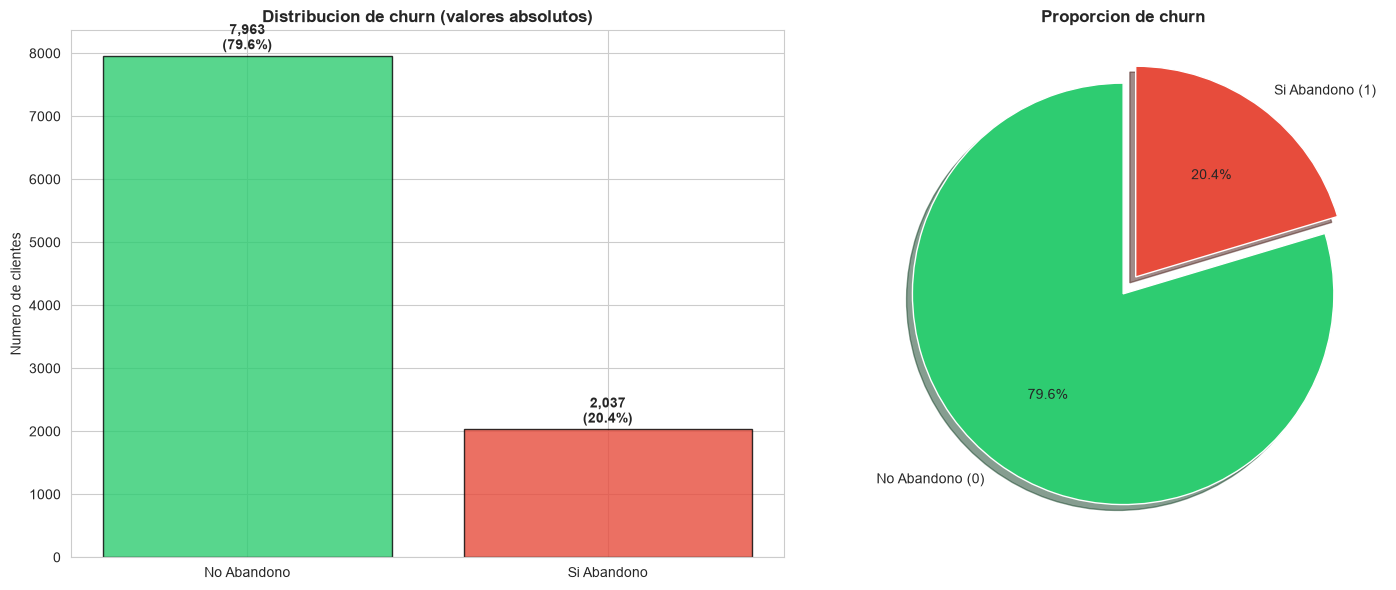

In [12]:
conteo = df['Exited'].value_counts()
porcentaje = df['Exited'].value_counts(normalize=True) * 100

print('ANALISIS DE LA VARIABLE OBJETIVO (Exited)')
print('=' * 70)
print(f'Clientes que NO abandonaron (0): {conteo[0]:,} ({porcentaje[0]:.2f}%)')
print(f'Clientes que SI abandonaron (1): {conteo[1]:,} ({porcentaje[1]:.2f}%)')
print(f'Tasa de churn: {porcentaje[1]:.2f}%')
print(f'Ratio de desbalance: {conteo[0]/conteo[1]:.2f} a 1')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].bar(['No Abandono', 'Si Abandono'], conteo.values,
            color=['#2ecc71', '#e74c3c'], alpha=0.8, edgecolor='black')
axes[0].set_ylabel('Numero de clientes')
axes[0].set_title('Distribucion de churn (valores absolutos)', fontweight='bold')
for i, v in enumerate(conteo.values):
    axes[0].text(i, v + 100, f'{v:,}\n({porcentaje.values[i]:.1f}%)',
                 ha='center', fontweight='bold')
axes[1].pie(conteo.values, labels=['No Abandono (0)', 'Si Abandono (1)'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90,
            explode=(0, 0.1), shadow=True)
axes[1].set_title('Proporcion de churn', fontweight='bold')
plt.tight_layout()
plt.show()

**El desbalance de clases y por qué es tan importante:** De los diez mil clientes, 7.963
(el 79,6%) permanecen activos y solo 2.037 (el 20,4%) abandonaron. La proporción es de casi 4 a 1. Las clases están desbalanceadas, algo típico en los problemas de churn.

Esto tiene una consecuencia que condiciona todo el trabajo. Si construyera un modelo que
simplemente predijera que ningún cliente abandona, acertaría el 79,6% de las veces, porque ese
es el porcentaje que efectivamente no se va. Un accuracy del 79,6% suena bien, pero ese modelo
sería inútil: no detectaría a ni un solo cliente en riesgo, que es justo lo que el banco
necesita. Por eso, en un problema desbalanceado, el accuracy engaña, y debo apoyarme en métricas
como precision, recall y F1. Y por eso, más adelante, entrenaré el modelo con una técnica que
compensa el desbalance.

## 4. Análisis Exploratorio de Datos (EDA)

Ahora exploro las relaciones entre las variables y el churn, para descubrir los patrones que el
modelo va a aprovechar.

### 4.1 Variables categóricas frente al churn

Analizo la tasa de churn dentro de cada categoría, para ver cuáles se asocian con más
abandono.

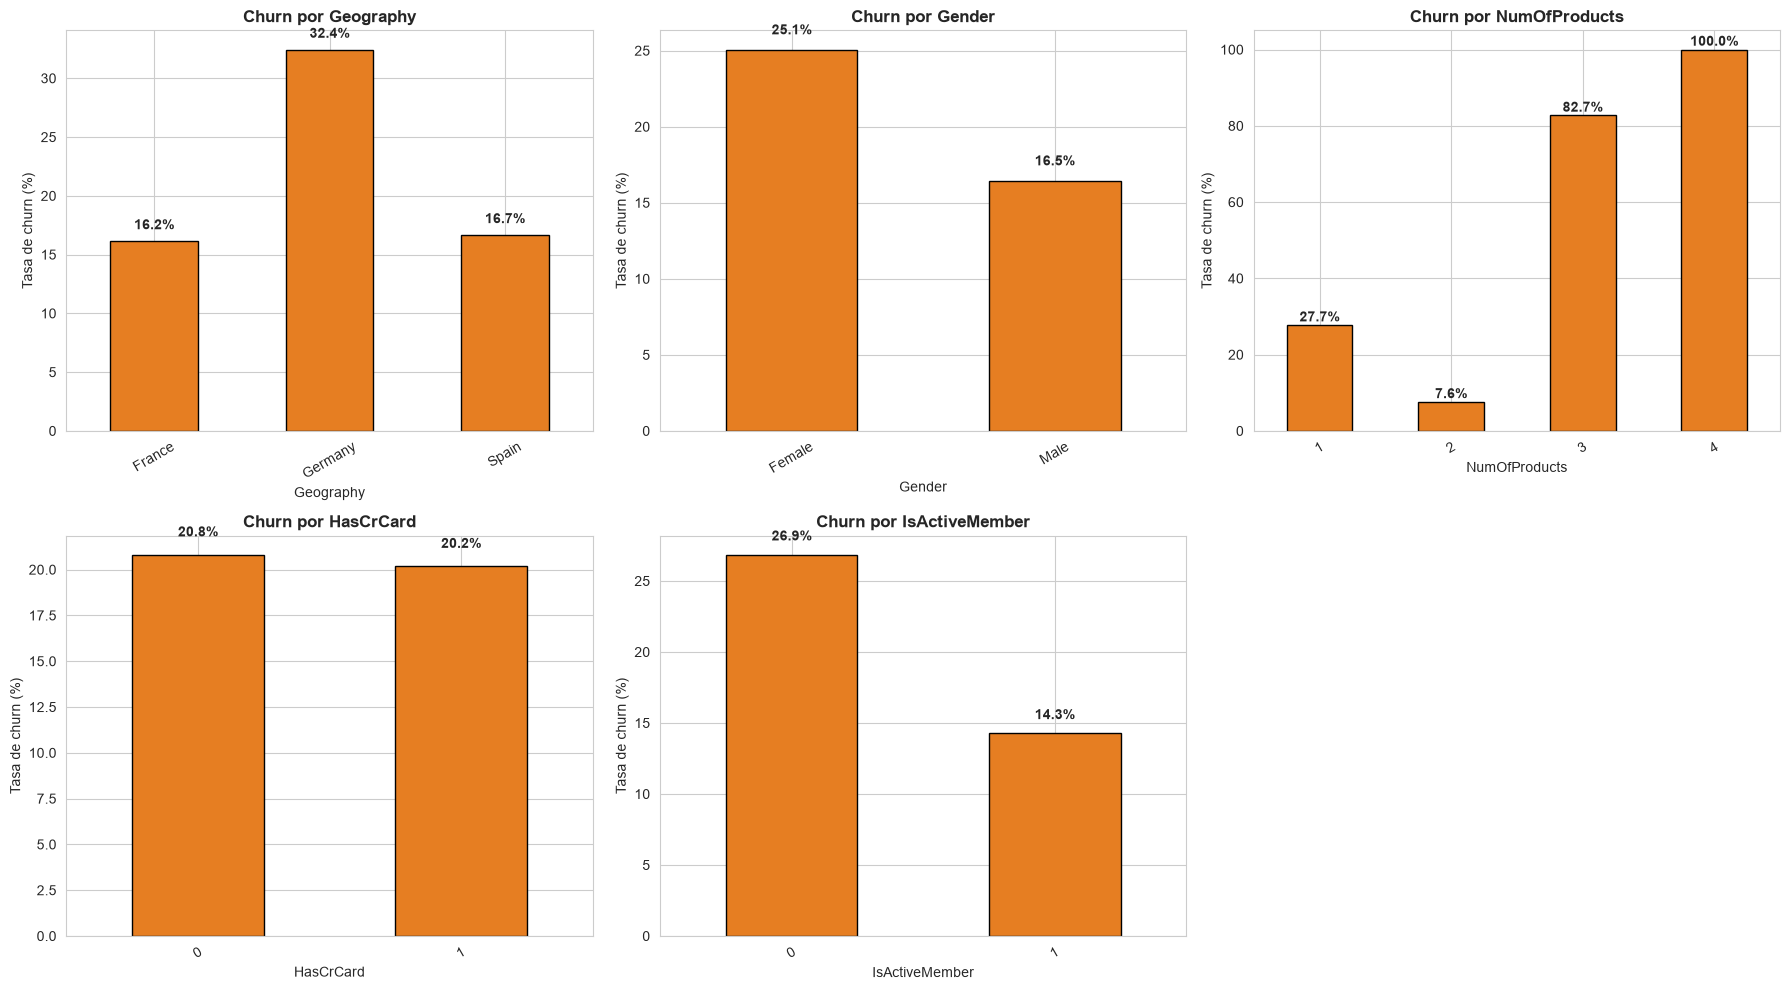

In [15]:
variables_cat = ['Geography', 'Gender', 'NumOfProducts', 'HasCrCard', 'IsActiveMember']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, var in enumerate(variables_cat):
    tasa = df.groupby(var)['Exited'].mean() * 100
    tasa.plot(kind='bar', ax=axes[idx], color='#e67e22', edgecolor='black')
    axes[idx].set_xlabel(var)
    axes[idx].set_ylabel('Tasa de churn (%)')
    axes[idx].set_title(f'Churn por {var}', fontweight='bold')
    axes[idx].tick_params(axis='x', rotation=30)
    for i, v in enumerate(tasa):
        axes[idx].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

axes[-1].axis('off')
plt.tight_layout()
plt.show()

**Los hallazgos de las variables categóricas, uno por uno.**

**El país es el primer hallazgo fuerte:** Alemania tiene una tasa de churn del 32,4%, el doble
que Francia (16,2%) y España (16,7%). Mientras dos países se mantienen cerca del promedio
general, Alemania se dispara. Esto apunta a un problema específico del mercado alemán que el
banco debería investigar.

**El género:** Las mujeres abandonan más que los hombres: 25,1% frente a 16,5%. Es una
diferencia considerable, las mujeres se van a una tasa un 52% mayor.

**El número de productos es el hallazgo más sorprendente:** El patrón es contraintuitivo. Con 1
producto, el churn es del 27,7%. Con 2 productos cae al 7,6%, el punto óptimo. Pero con 3
productos salta al 82,7%, y con 4 productos abandonan todos, el 100%. Contratar más productos no
fideliza, al contrario: tener 3 o más es señal de problemas, no de lealtad. Probablemente son
clientes a los que se les vendieron productos que no necesitaban o que acumularon malas
experiencias.

**Tener tarjeta de crédito:** apenas cambia la tasa de churn, lo que anticipa que no será un
predictor importante.

**Ser miembro activo protege:** Los activos abandonan al 14,3%, los inactivos al 26,9%, casi el
doble. Fomentar la actividad de los clientes es una vía clara de retención.

### 4.2 Variables numéricas frente al churn

Uso diagramas de caja para comparar la distribución de cada variable numérica entre los que se
van y los que se quedan.

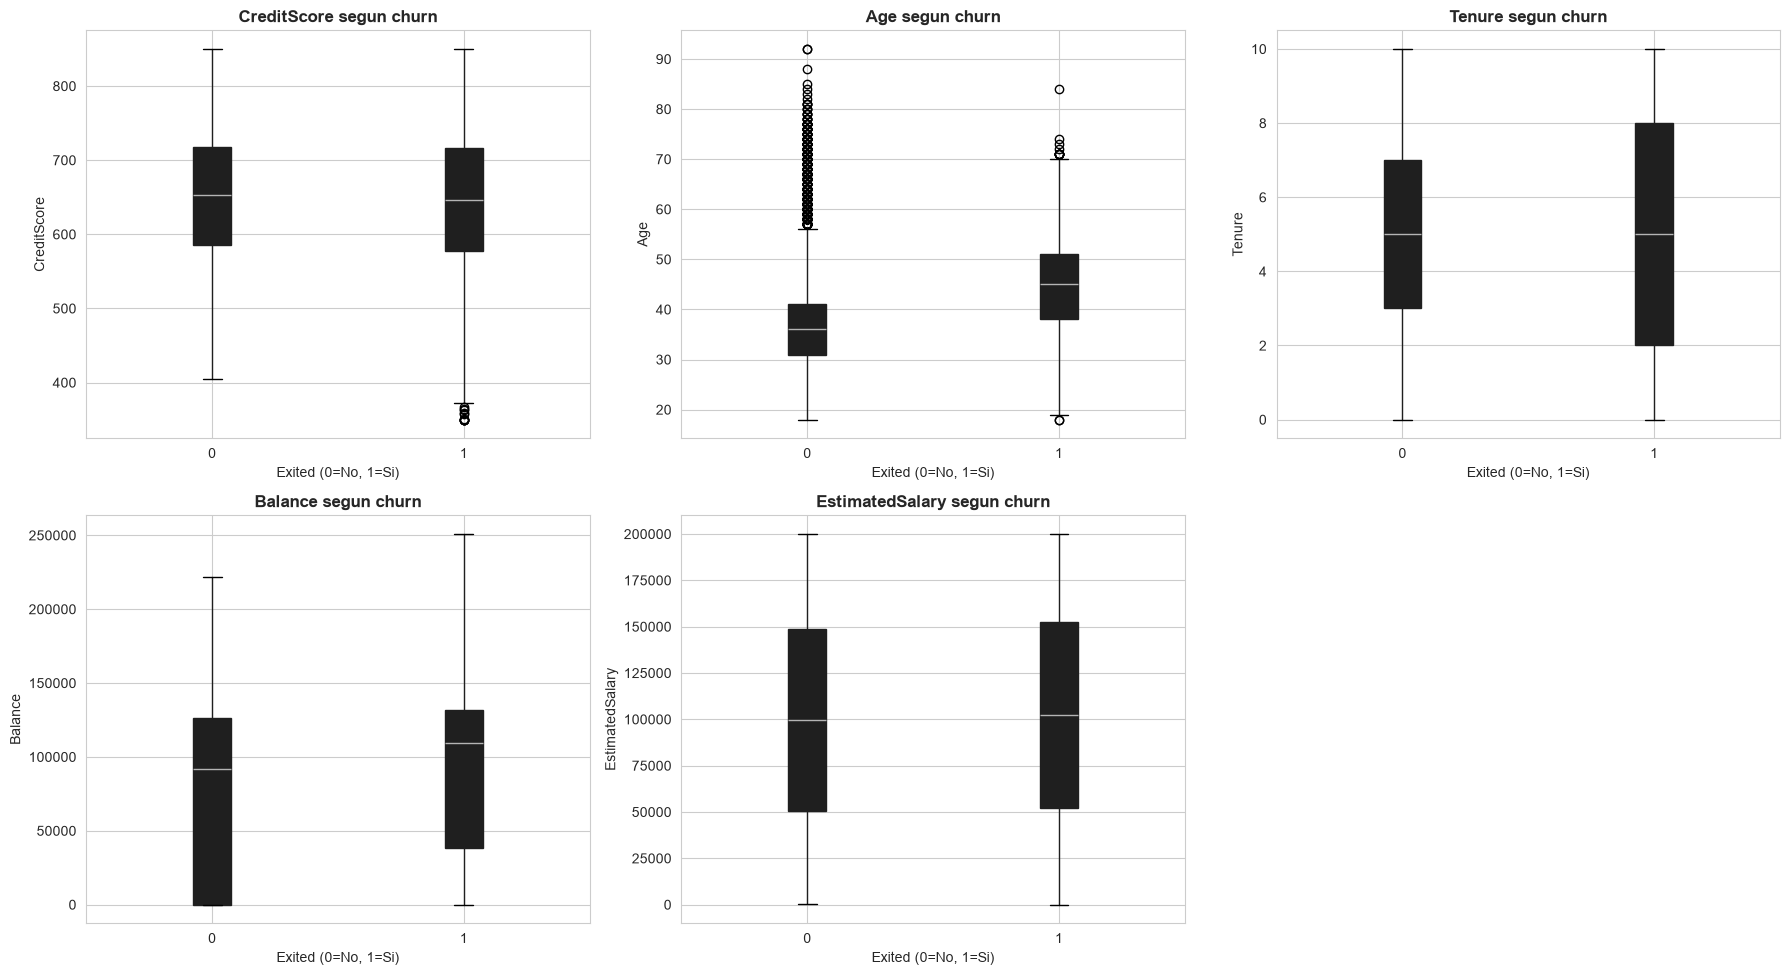

COMPARACION DE MEDIAS (No churn frente a churn)
  CreditScore       : No churn =     651.85 | Churn =     645.35 | Dif =      -6.50
  Age               : No churn =      37.41 | Churn =      44.84 | Dif =      +7.43
  Tenure            : No churn =       5.03 | Churn =       4.93 | Dif =      -0.10
  Balance           : No churn =   72745.30 | Churn =   91108.54 | Dif =  +18363.24
  EstimatedSalary   : No churn =   99738.39 | Churn =  101465.68 | Dif =   +1727.29


In [16]:
variables_num = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, var in enumerate(variables_num):
    df.boxplot(column=var, by='Exited', ax=axes[idx], patch_artist=True)
    axes[idx].set_xlabel('Exited (0=No, 1=Si)')
    axes[idx].set_ylabel(var)
    axes[idx].set_title(f'{var} segun churn', fontweight='bold')

plt.suptitle('')
axes[-1].axis('off')
plt.tight_layout()
plt.show()

print('COMPARACION DE MEDIAS (No churn frente a churn)')
print('=' * 70)
for var in variables_num:
    m0 = df[df['Exited']==0][var].mean()
    m1 = df[df['Exited']==1][var].mean()
    dif = m1 - m0
    print(f'  {var:18s}: No churn = {m0:10.2f} | Churn = {m1:10.2f} | Dif = {dif:+10.2f}')

**Los hallazgos de las variables numéricas.**

**La edad es el predictor numérico más claro:** Los clientes que abandonan tienen 44,8 años en
promedio, frente a 37,4 de los que se quedan, una diferencia de más de 7 años. En los boxplots
se ve cómo la caja de los que se van (Exited igual a 1) está desplazada hacia edades mayores. El
perfil de riesgo son los clientes mayores de 45 años.

**El saldo presenta un patrón contraintuitivo:** Los que abandonan tienen más saldo en promedio
(unos 91 mil) que los que se quedan (unos 73 mil), una diferencia de más de 18 mil. Uno
esperaría que quien tiene más dinero en el banco esté más atado, pero ocurre lo contrario. Una
posible explicación es que estos clientes con alto saldo esperan un mejor servicio o mejores
rendimientos, y se van si no los reciben.

**El CreditScore casi no distingue** entre los dos grupos, la diferencia es mínima, así que no
será un predictor fuerte. La antigüedad (Tenure) y el salario tampoco muestran diferencias
marcadas.

### 4.3 Matriz de correlación

Reviso las correlaciones entre variables, tanto para ver cuáles se relacionan con el churn como
para detectar posible multicolinealidad (variables predictoras muy correlacionadas entre sí).

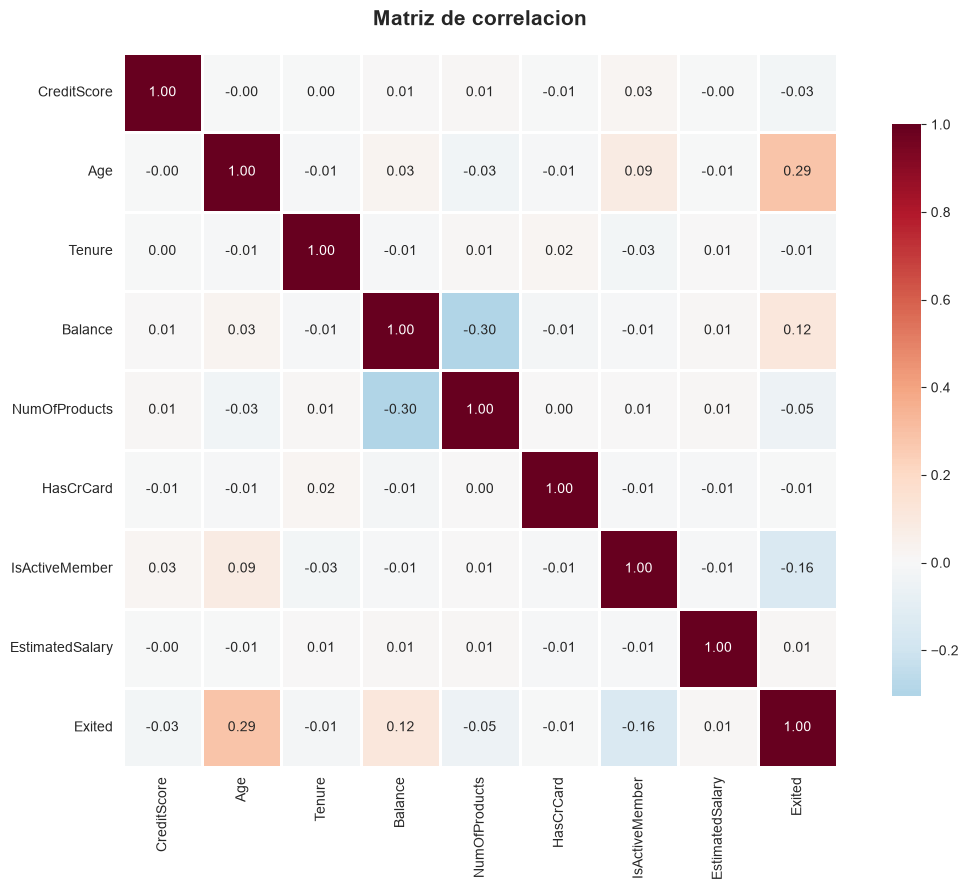

Correlaciones con el churn (ordenadas por magnitud):
Age                0.2853
IsActiveMember    -0.1561
Balance            0.1185
NumOfProducts     -0.0478
CreditScore       -0.0271
Tenure            -0.0140
EstimatedSalary    0.0121
HasCrCard         -0.0071


In [17]:
vars_corr = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
             'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']
corr = df[vars_corr].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=1, cbar_kws={'shrink': 0.8})
plt.title('Matriz de correlacion', fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print('Correlaciones con el churn (ordenadas por magnitud):')
churn_corr = corr['Exited'].drop('Exited').sort_values(ascending=False, key=abs)
print(churn_corr.round(4).to_string())

**Cómo leo la matriz:** Me fijo en la fila de Exited, que muestra la correlación de cada
variable con el churn. Un valor cercano a cero indica poca relación lineal, uno alejado indica
relación fuerte.

**Lo que encuentro.** La edad tiene la correlación positiva más fuerte con el churn (alrededor
de 0,29): es el mejor predictor individual, a más edad, más abandono. Ser miembro activo tiene
la correlación negativa más marcada (cerca de menos 0,16): confirma que la actividad protege. El
saldo aparece con correlación positiva leve, coherente con el patrón contraintuitivo que vi. El
resto de variables tienen correlaciones bajas con el churn.

**Sobre la multicolinealidad:** Entre las variables predictoras no hay ninguna correlación alta
(ninguna cercana a más o menos 1). La más notable es la relación negativa entre el saldo y el
número de productos, pero es moderada. Esto anticipa que no habrá multicolinealidad
problemática, algo que es bueno para poder interpretar los coeficientes del modelo con
confianza.

## 5. Preparación de los Datos

Preparo los datos para el modelo en cinco pasos: elimino columnas inútiles, codifico las
categóricas, separo predictoras y objetivo, divido en entrenamiento y prueba, y escalo las
variables numéricas continuas.

### 5.1 Limpieza: elimino las columnas de identificación

In [19]:
df_modelo = df.copy()

columnas_eliminar = ['RowNumber', 'CustomerId', 'Surname']
df_modelo = df_modelo.drop(columns=columnas_eliminar)

print('Columnas eliminadas:', columnas_eliminar)
print('Columnas restantes:', list(df_modelo.columns))

Columnas eliminadas: ['RowNumber', 'CustomerId', 'Surname']
Columnas restantes: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


Elimino RowNumber, CustomerId y Surname. Son identificadores: no describen el comportamiento
del cliente ni influyen en su decisión de irse. El apellido de una persona no predice su churn.
Dejarlas solo agregaría ruido al modelo.

### 5.2 Codificación de las variables categóricas

Los modelos solo operan con números, así que convierto las dos variables de texto. Uso una
técnica distinta para cada una, según su naturaleza.

In [20]:
# Gender es binaria (Female, Male): uso Label Encoding, 0 y 1.
df_modelo['Gender'] = df_modelo['Gender'].map({'Female': 0, 'Male': 1})

# Geography tiene tres categorias sin orden: uso One-Hot Encoding.
df_modelo = pd.get_dummies(df_modelo, columns=['Geography'], drop_first=True, dtype=int)

print('Columnas despues de codificar:')
print(list(df_modelo.columns))
df_modelo.head()

Columnas despues de codificar:
['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany', 'Geography_Spain']


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,0,0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0,1
2,502,0,42,8,159660.80,3,1,0,113931.57,1,0,0
3,699,0,39,1,0.00,2,0,0,93826.63,0,0,0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0,1


### Exporto el dataset transformado para los siguientes avances

Guardo el dataset ya limpio y codificado, para reutilizarlo como punto de partida en los
avances 2 y 3. Exporto la versión con el encoding aplicado pero sin escalar, porque el escalado
depende de la división en entrenamiento y prueba, que cada avance realiza por su cuenta para
evitar la fuga de datos. Así, los siguientes avances solo cargan este archivo, dividen y escalan,
sin repetir la limpieza ni la codificación.

In [21]:
# Exporto el dataset transformado (limpio y codificado, sin escalar).
# Este archivo sera el punto de partida de los avances 2 y 3.
# No lo escalo aqui porque el escalado se hace tras dividir train/test en cada avance.
df_modelo.to_csv('churn_transformado.csv', index=False)
print('Dataset transformado exportado como churn_transformado.csv')
print(f'Filas: {df_modelo.shape[0]}, Columnas: {df_modelo.shape[1]}')
print('Columnas:', list(df_modelo.columns))

Dataset transformado exportado como churn_transformado.csv
Filas: 10000, Columnas: 12
Columnas: ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany', 'Geography_Spain']


**Por qué dos técnicas distintas.**

**El género con Label Encoding:** Le asigno 0 a Female y 1 a Male. Con solo dos categorías, esto
es seguro: no invento ningún orden ni distancia falsa, son solo dos etiquetas.

**El país con One-Hot Encoding:** Aquí no puedo asignar 0, 1, 2 a los tres países, porque eso
implicaría un orden (que España es mayor que Alemania, que hay el doble de distancia a uno que a
otro) que no existe. Los países son categorías sin jerarquía. One-Hot crea una columna por país
con 0 o 1, tratándolos como independientes.

**El drop_first:** Elimina una columna redundante (la de Francia). Si un cliente tiene 0 en
Germany y 0 en Spain, es de Francia por descarte. Dejar la tercera columna causaría
multicolinealidad perfecta, lo que se conoce como la trampa de la variable ficticia. Por eso
quedan solo Geography_Germany y Geography_Spain.

### 5.3 Separación de predictoras (X) y objetivo (y)

In [22]:
X = df_modelo.drop('Exited', axis=1)
y = df_modelo['Exited']

print('Predictoras (X):', X.shape[1], 'columnas')
print('Columnas:', list(X.columns))
print('Objetivo (y):', y.name)

Predictoras (X): 11 columnas
Columnas: ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain']
Objetivo (y): Exited


Separo los datos en X (las once variables que uso para predecir) e y (la columna Exited, lo
que quiero predecir). El modelo aprenderá la relación entre las características del cliente y su
decisión de abandonar.

### 5.4 División en entrenamiento y prueba

Divido antes de escalar, para evitar la fuga de datos.

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print('DIVISION TRAIN / TEST')
print('=' * 70)
print(f'Entrenamiento: {X_train.shape[0]} clientes')
print(f'Prueba:        {X_test.shape[0]} clientes')
print(f'Churn en entrenamiento: {y_train.mean()*100:.2f}%')
print(f'Churn en prueba:        {y_test.mean()*100:.2f}%')

DIVISION TRAIN / TEST
Entrenamiento: 8000 clientes
Prueba:        2000 clientes
Churn en entrenamiento: 20.38%
Churn en prueba:        20.35%


**Las tres decisiones de esta división.**

El test_size de 0,20 reserva el 20% de los datos para la prueba final y usa el 80% para
entrenar, una proporción estándar.

El stratify igual a y es clave con datos desbalanceados: garantiza que la proporción de churn
(20,4%) se mantenga idéntica en ambos conjuntos. El resultado lo confirma, ambos quedan en torno
al 20,4%.

El random_state de 42 fija la aleatoriedad de la partición, para que el notebook sea
reproducible: cualquiera que lo ejecute obtiene la misma división y los mismos resultados.

**Por qué divido antes de escalar:** El escalado calcula promedios y desviaciones. Si escalara
antes de dividir, esos cálculos usarían información del conjunto de prueba, que se filtraría al
entrenamiento. Eso es la fuga de datos, y hace que el modelo parezca mejor de lo que será con
datos nuevos. Por eso divido primero.

### 5.5 Escalado de las variables numéricas continuas

Escalo solo las variables continuas, no las binarias.

In [24]:
# Escalo unicamente las variables numericas continuas.
# Las binarias (HasCrCard, IsActiveMember, Gender) y las dummies de pais ya estan
# en escala 0-1, asi que no las escalo: hacerlo no aporta y ademas me permite
# interpretar sus coeficientes de forma directa.
cols_escalar = ['CreditScore', 'Age', 'Tenure', 'Balance',
                'NumOfProducts', 'EstimatedSalary']

scaler = StandardScaler()

X_train_esc = X_train.copy()
X_test_esc = X_test.copy()

# Ajusto el scaler SOLO con entrenamiento (fit_transform) y aplico a prueba (transform)
X_train_esc[cols_escalar] = scaler.fit_transform(X_train[cols_escalar])
X_test_esc[cols_escalar] = scaler.transform(X_test[cols_escalar])

print('Variables escaladas (solo las continuas).')
print('Comparacion antes y despues, primeras filas:')
print('\nANTES:')
print(X_train[cols_escalar].head(3))
print('\nDESPUES:')
print(X_train_esc[cols_escalar].head(3).round(3))

Variables escaladas (solo las continuas).
Comparacion antes y despues, primeras filas:

ANTES:
      CreditScore  Age  Tenure    Balance  NumOfProducts  EstimatedSalary
2151          753   57       7       0.00              1        159475.08
8392          739   32       3  102128.27              1         63981.37
5006          755   37       0  113865.23              2        117396.25

DESPUES:
      CreditScore    Age  Tenure  Balance  NumOfProducts  EstimatedSalary
2151        1.059  1.715   0.685   -1.226         -0.910            1.042
8392        0.914 -0.660  -0.696    0.413         -0.910           -0.624
5006        1.079 -0.185  -1.732    0.602          0.809            0.308


**Por qué escalo, y por qué solo las continuas.**

La regresión logística es sensible a la escala de las variables. Las continuas tienen rangos muy
distintos: el salario llega a cientos de miles, la edad a decenas, el saldo a cientos de miles.
Sin escalar, el modelo le daría más peso al salario solo por la magnitud de sus números.
StandardScaler transforma cada variable para que tenga media cero y desviación uno, poniéndolas
a todas en igualdad de condiciones.

Escalo solo las seis variables continuas. Las binarias (HasCrCard, IsActiveMember, Gender) y las
dummies de país ya valen 0 o 1, una escala pequeña y uniforme, así que no necesitan escalado.
Además, dejarlas sin escalar me permite interpretar sus coeficientes de forma directa: el
coeficiente de IsActiveMember será el efecto de pasar de inactivo (0) a activo (1), una lectura
clara que se perdería si las escalara.

**La prevención de la fuga de datos.** Ajusto el scaler solo con el entrenamiento
(fit_transform) y aplico esa misma transformación a la prueba (transform). Así la información de
la prueba nunca contamina el entrenamiento.

## 6. Implementación de la Regresión Logística

### 6.1 Entrenamiento del modelo

In [25]:
# Entreno la regresion logistica.
# Uso class_weight='balanced' para manejar el desbalance de clases: como los que
# abandonan son solo el 20%, esta opcion le da mas peso a esa clase minoritaria
# durante el entrenamiento, para que el modelo no la ignore. Manejar el desbalance
# es uno de los objetivos del proyecto.
# max_iter=1000 asegura la convergencia. random_state=42 para reproducibilidad.
modelo_lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

modelo_lr.fit(X_train_esc, y_train)

print('Modelo entrenado')
print(f'Numero de variables: {len(modelo_lr.coef_[0])}')
print(f'Iteraciones hasta converger: {modelo_lr.n_iter_[0]}')

Modelo entrenado
Numero de variables: 11
Iteraciones hasta converger: 10


**Por qué uso class_weight balanced:** El dataset está desbalanceado (80% activos, 20%
abandonos). Un modelo sin ajuste tendería a enfocarse en acertarle a la mayoría e ignorar a la
minoría, que es justo la que me interesa detectar. La opción balanced le da más peso a los casos
de churn durante el entrenamiento, en proporción inversa a su frecuencia. Esto obliga al modelo
a prestarles atención. Manejar el desbalance es uno de los objetivos de aprendizaje que la
consigna del proyecto pide de forma explícita.

Esta decisión tiene una consecuencia que veré en la evaluación: el modelo detectará más
abandonos (recall alto) a costa de generar más falsas alarmas (precisión más baja). Para un
banco, ese intercambio es deseable, como explicaré.

### 6.2 Análisis de los coeficientes

In [26]:
coeficientes = pd.DataFrame({
    'Variable': X_train_esc.columns,
    'Coeficiente': modelo_lr.coef_[0],
    'Abs': np.abs(modelo_lr.coef_[0])
}).sort_values('Abs', ascending=False)

print('COEFICIENTES DEL MODELO')
print('=' * 70)
print(f'Intercepto: {modelo_lr.intercept_[0]:.4f}')
print()
print(coeficientes[['Variable', 'Coeficiente']].to_string(index=False))

COEFICIENTES DEL MODELO
Intercepto: 0.2906

         Variable  Coeficiente
   IsActiveMember    -0.881628
Geography_Germany     0.826281
              Age     0.801082
           Gender    -0.544552
          Balance     0.175114
      CreditScore    -0.086876
        HasCrCard    -0.067577
  Geography_Spain     0.058253
    NumOfProducts    -0.057931
  EstimatedSalary     0.050434
           Tenure    -0.018734


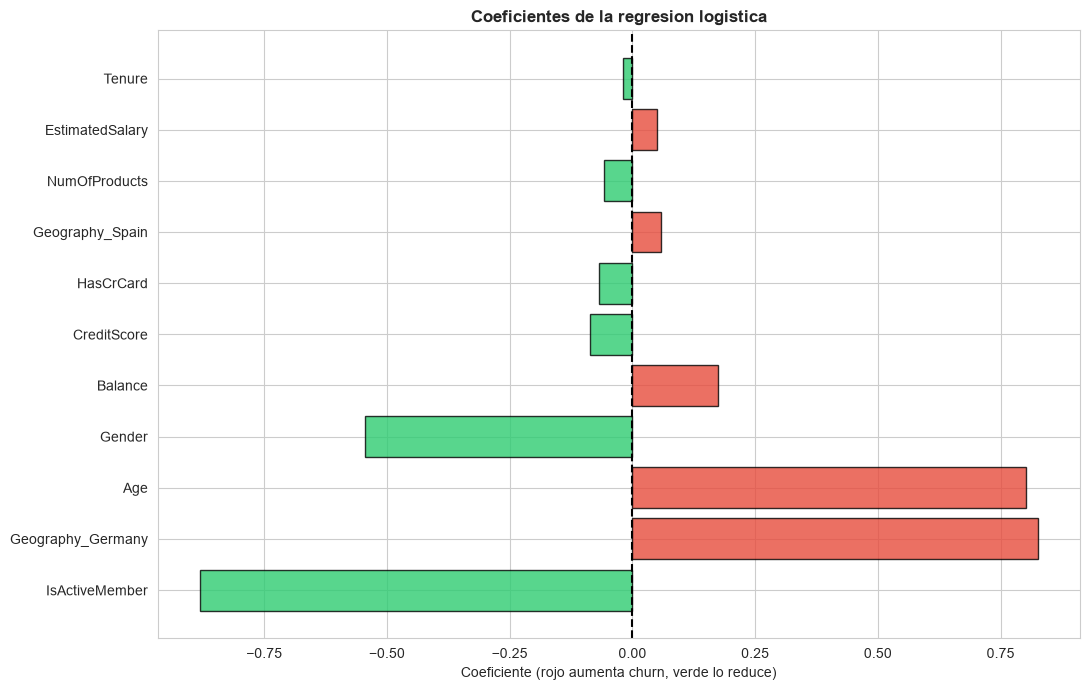

In [27]:
plt.figure(figsize=(11, 7))
colores = ['#e74c3c' if c > 0 else '#2ecc71' for c in coeficientes['Coeficiente']]
plt.barh(coeficientes['Variable'], coeficientes['Coeficiente'],
         color=colores, alpha=0.8, edgecolor='black')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1.5)
plt.xlabel('Coeficiente (rojo aumenta churn, verde lo reduce)')
plt.title('Coeficientes de la regresion logistica', fontweight='bold')
plt.tight_layout()
plt.show()

**Cómo interpreto los coeficientes:** Cada uno indica cómo afecta su variable al churn.
Positivo (rojo) empuja hacia el abandono, negativo (verde) protege. La magnitud indica la fuerza
del efecto.

**Las variables que más aumentan el churn:** Ser de Alemania tiene el coeficiente positivo más
alto (0,83), confirmando el hallazgo del EDA. La edad le sigue muy de cerca (0,80): a mayor
edad, más riesgo. El saldo también empuja al alza, de forma más leve.

**Las variables que reducen el churn:** Ser miembro activo tiene el coeficiente negativo más
fuerte (menos 0,88): es el mayor factor protector. El género (ser hombre) también protege (menos
0,54), lo que confirma que las mujeres abandonan más.

**Un detalle importante sobre el número de productos:** Su coeficiente es pequeño (cercano a
cero), a pesar de que en el EDA vimos que tenía un efecto brutal. Esto ocurre porque la regresión
logística es lineal, y el efecto de los productos no lo es: 2 productos es óptimo, pero 3 o 4
dispara el churn. El modelo lineal no puede capturar ese patrón en forma de U y termina
promediando los efectos opuestos hasta casi cancelarlos. Es una limitación de este modelo, y una
señal de que los modelos de árboles de los avances siguientes, que sí capturan relaciones no
lineales, podrían mejorar el resultado.

### 6.3 Odds ratios

In [28]:
odds = pd.DataFrame({
    'Variable': X_train_esc.columns,
    'Coeficiente': modelo_lr.coef_[0],
    'OddsRatio': np.exp(modelo_lr.coef_[0]),
    'Cambio_%': (np.exp(modelo_lr.coef_[0]) - 1) * 100
}).sort_values('OddsRatio', ascending=False)

print('ODDS RATIOS')
print('=' * 70)
print(odds.to_string(index=False))

ODDS RATIOS
         Variable  Coeficiente  OddsRatio   Cambio_%
Geography_Germany     0.826281   2.284806 128.480639
              Age     0.801082   2.227949 122.794917
          Balance     0.175114   1.191382  19.138183
  Geography_Spain     0.058253   1.059983   5.998350
  EstimatedSalary     0.050434   1.051727   5.172715
           Tenure    -0.018734   0.981441  -1.855945
    NumOfProducts    -0.057931   0.943715  -5.628505
        HasCrCard    -0.067577   0.934655  -6.534462
      CreditScore    -0.086876   0.916790  -8.320967
           Gender    -0.544552   0.580102 -41.989827
   IsActiveMember    -0.881628   0.414108 -58.589200


**Cómo interpreto los odds ratios:** El odds ratio es la exponencial del coeficiente, y es
más fácil de leer: es el factor por el que se multiplican los odds de churn cuando la variable
aumenta. Mayor a 1 aumenta el riesgo, menor a 1 lo reduce.

**Los más relevantes:** Ser de Alemania tiene odds ratio 2,28: un cliente alemán tiene sus odds
de abandono multiplicados por 2,28 frente a la referencia (Francia), más del doble. La edad tiene
2,23: por cada desviación estándar más de edad, los odds de churn se multiplican por 2,23. En el
otro extremo, ser miembro activo tiene odds ratio 0,41: reduce los odds de abandono al 41% de los
de un inactivo, menos de la mitad. Y ser hombre, 0,58: reduce los odds respecto a ser mujer.

### 6.4 Intervalos de confianza y significancia estadística

Uso statsmodels para obtener los intervalos de confianza y los p-valores de cada variable. Esta
librería es el estándar de análisis estadístico en Python y entrega estos valores directamente.
La uso como análisis complementario para evaluar la significancia de cada variable.

In [29]:
# statsmodels requiere agregar una constante (el intercepto) de forma explicita.
X_train_sm = sm.add_constant(X_train_esc)
modelo_sm = sm.Logit(y_train.values, X_train_sm).fit(disp=0)

print(modelo_sm.summary())

                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                 8000
Model:                          Logit   Df Residuals:                     7988
Method:                           MLE   Df Model:                           11
Date:              lun., 03 ago. 2026   Pseudo R-squ.:                  0.1511
Time:                        08:40:20   Log-Likelihood:                -3433.3
converged:                       True   LL-Null:                       -4044.5
Covariance Type:            nonrobust   LLR p-value:                2.584e-255
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -0.9946      0.076    -13.102      0.000      -1.143      -0.846
CreditScore          -0.0861      0.030     -2.849      0.004      -0.145      -0.027
Gender               -0.

**Cómo leo este resumen:** Me interesan dos columnas.

**La columna P mayor que z (el p-valor):** Indica si el efecto de cada variable es
estadísticamente significativo, es decir, si es real o pudo salir por azar. Si es menor a 0,05,
la variable es significativa.

**Las columnas 0.025 y 0.975 (el intervalo de confianza al 95%).** Dan el rango donde
probablemente está el verdadero coeficiente. Si el intervalo no incluye el cero, la variable es
significativa; si lo incluye, su efecto podría no ser real.

**Qué encuentro:** Son significativas (p-valor 0,000 o cercano): la edad, ser de Alemania, ser
miembro activo, el género, el saldo y el CreditScore. Ser miembro activo tiene el efecto más
fuerte. En cambio, NO son significativas: la antigüedad (Tenure, p-valor 0,50), tener tarjeta
(HasCrCard, 0,28), el salario (0,12) y ser de España (0,57). Sus intervalos incluyen el cero, lo
que significa que su efecto sobre el churn no se distingue de cero con estos datos.

Este resultado es informativo por sí mismo: le dice al banco que factores como el salario, la
antigüedad o tener tarjeta no explican el abandono, mientras que la edad, el país, la actividad y
el género sí lo hacen.

## 7. Evaluación del Modelo

Evalúo el modelo sobre el conjunto de prueba, que no participó en el entrenamiento.

### 7.1 Predicciones

In [30]:
y_pred = modelo_lr.predict(X_test_esc)
y_prob = modelo_lr.predict_proba(X_test_esc)[:, 1]

print('Predicciones generadas sobre el conjunto de prueba.')
print(f'Total de clientes evaluados: {len(y_pred)}')

Predicciones generadas sobre el conjunto de prueba.
Total de clientes evaluados: 2000


Genero dos salidas. Las predicciones (y_pred) son la decisión final del modelo, 0 o 1,
aplicando el umbral de 0,5. Las probabilidades (y_prob) son los valores crudos entre 0 y 1 antes
del umbral, que necesito para la curva ROC.

### 7.2 Matriz de confusión

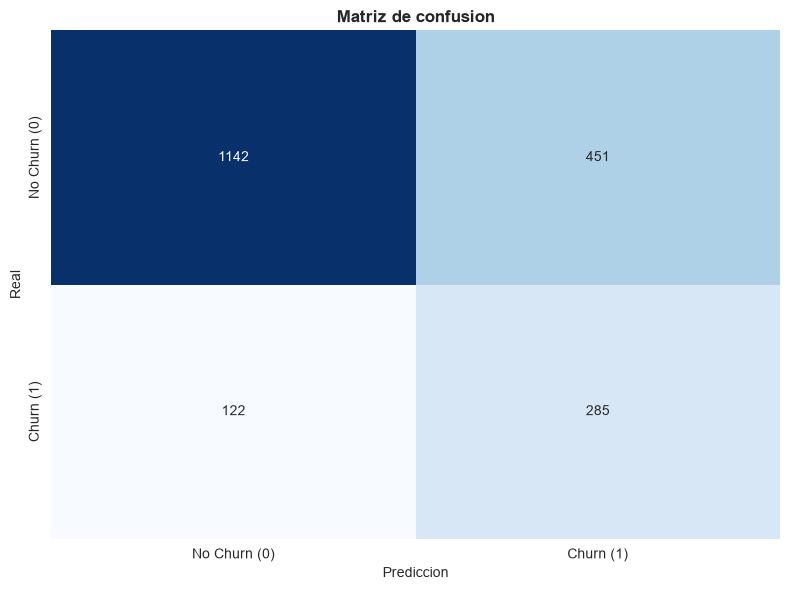

DESGLOSE DE LA MATRIZ
Verdaderos negativos (TN): 1142 - predijo No Churn y acerto
Verdaderos positivos (TP):  285 - predijo Churn y acerto
Falsos positivos (FP):      451 - predijo Churn pero no era (falsa alarma)
Falsos negativos (FN):      122 - predijo No Churn pero si era (cliente perdido)


In [31]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Churn (0)', 'Churn (1)'],
            yticklabels=['No Churn (0)', 'Churn (1)'])
plt.xlabel('Prediccion')
plt.ylabel('Real')
plt.title('Matriz de confusion', fontweight='bold')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print('DESGLOSE DE LA MATRIZ')
print('=' * 70)
print(f'Verdaderos negativos (TN): {tn:4d} - predijo No Churn y acerto')
print(f'Verdaderos positivos (TP): {tp:4d} - predijo Churn y acerto')
print(f'Falsos positivos (FP):     {fp:4d} - predijo Churn pero no era (falsa alarma)')
print(f'Falsos negativos (FN):     {fn:4d} - predijo No Churn pero si era (cliente perdido)')

**Cómo leo la matriz:** Las filas son la realidad, las columnas la predicción. Los cuatro
cuadrantes, con mis valores:

Verdaderos negativos (1.142): clientes activos que el modelo predijo activos. Acierto.

Verdaderos positivos (285): clientes que se fueron y el modelo detectó. Acierto, el más valioso.

Falsos positivos (451): clientes activos que el modelo marcó como riesgo. Error de falsa alarma:
el banco haría una retención innecesaria.

Falsos negativos (122): clientes que se fueron y el modelo NO detectó. El error más costoso, son
clientes perdidos sin oportunidad de retenerlos.

**En el contexto del churn**, el falso negativo es más costoso que el falso positivo. Una falsa
alarma solo gasta un esfuerzo de retención; un cliente no detectado es un cliente perdido. Por eso
me interesa que el modelo minimice los falsos negativos, aunque genere más falsas alarmas. Esa es
la lógica detrás de haber usado class_weight balanced.

### 7.3 Métricas de clasificación

In [32]:
accuracy = accuracy_score(y_test, y_pred)

print('REPORTE DE CLASIFICACION')
print('=' * 70)
print(classification_report(y_test, y_pred,
                            target_names=['No Churn', 'Churn'], digits=4))

reporte = classification_report(y_test, y_pred, output_dict=True)
precision_churn = reporte['1']['precision']
recall_churn = reporte['1']['recall']
f1_churn = reporte['1']['f1-score']

print('METRICAS PARA LA CLASE CHURN')
print('=' * 70)
print(f'Accuracy (global): {accuracy:.4f} ({accuracy*100:.1f}%)')
print(f'Precision: {precision_churn:.4f}')
print(f'Recall:    {recall_churn:.4f}')
print(f'F1-Score:  {f1_churn:.4f}')

REPORTE DE CLASIFICACION
              precision    recall  f1-score   support

    No Churn     0.9035    0.7169    0.7994      1593
       Churn     0.3872    0.7002    0.4987       407

    accuracy                         0.7135      2000
   macro avg     0.6454    0.7086    0.6491      2000
weighted avg     0.7984    0.7135    0.7382      2000

METRICAS PARA LA CLASE CHURN
Accuracy (global): 0.7135 (71.4%)
Precision: 0.3872
Recall:    0.7002
F1-Score:  0.4987


**Qué significa cada métrica, con mis valores.**

**Accuracy (0,71):** El porcentaje total de aciertos. Es más bajo que el 0,80 que daría un
modelo que predijera "nadie se va", y eso es deseable en este caso: el modelo sacrifica exactitud
global a cambio de detectar a la minoría que importa. Aquí se ve por qué el accuracy engaña con
datos desbalanceados.

**Precision (0,39):** De todos los que el modelo marcó como churn, cuántos realmente lo eran. Un
39% significa que de cada 100 alarmas, unas 39 son ciertas. Es baja, el precio de priorizar el
recall.

**Recall (0,70):** De todos los que realmente se fueron, cuántos detecté. Es la métrica clave
para el banco: capto el 70% de los clientes en riesgo. Es la que priorizo.

**F1-Score (0,50):** La media armónica de precision y recall, una medida balanceada entre ambas.

**El compromiso entre precision y recall:** Al usar class_weight balanced, elegí priorizar el
recall sobre la precisión. Para un banco tiene sentido: es preferible hacerle una oferta de
retención de más a alguien que no se iba (falso positivo, costo bajo) que perder a un cliente sin
detectarlo (falso negativo, costo alto). El costo de los dos errores no es simétrico, y por eso
inclino el modelo hacia el recall.

### 7.4 Curva ROC y AUC

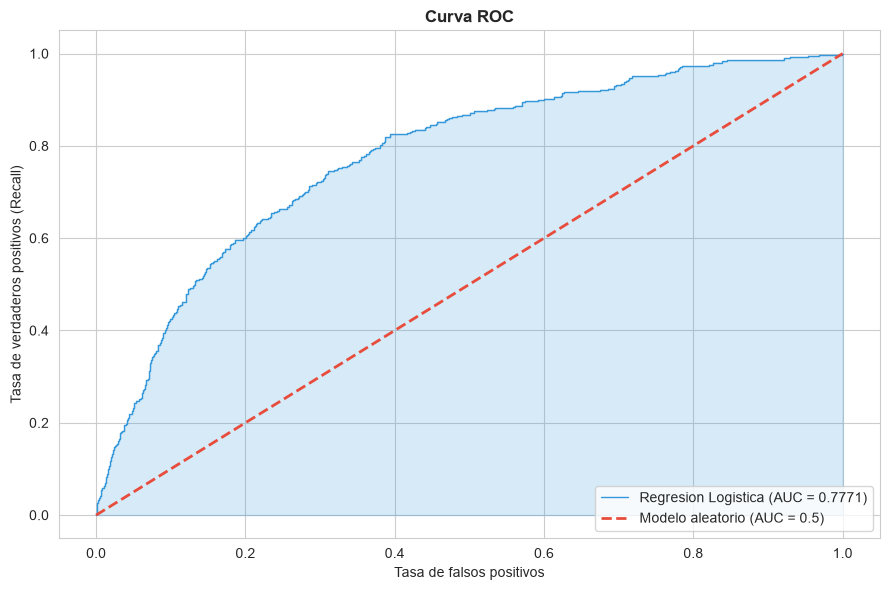

AUC: 0.7771


In [33]:
fpr, tpr, umbrales = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(9, 6))
plt.plot(fpr, tpr, color='#3498db', linewidth=1, label=f'Regresion Logistica (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='#e74c3c', linestyle='--', linewidth=2, label='Modelo aleatorio (AUC = 0.5)')
plt.fill_between(fpr, tpr, alpha=0.2, color='#3498db')
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos (Recall)')
plt.title('Curva ROC', fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f'AUC: {auc:.4f}')

**Qué es la curva ROC:** Hasta ahora evalué el modelo con el umbral fijo de 0,5. Pero ese
umbral se puede mover, y la curva ROC muestra el desempeño del modelo en todos los umbrales a la
vez. Cada punto de la curva es un umbral distinto, cruzando la tasa de verdaderos positivos
(recall) contra la de falsos positivos (falsas alarmas).

**Qué es el AUC:** Es el área bajo esa curva, un resumen en un solo número. Un AUC de 0,5 es un
modelo que no distingue nada (la diagonal roja); uno de 1,0 sería perfecto. Cuanto más se acerque
la curva a la esquina superior izquierda, mejor.

**Mi resultado:** Obtuve un AUC de 0,777. Se interpreta así: si tomo al azar un cliente que se
fue y uno que se quedó, el modelo le asigna mayor probabilidad de churn al que efectivamente se
fue el 77,7% de las veces. Según las escalas de referencia, un AUC entre 0,7 y 0,8 es un buen
modelo. El AUC es una de las mejores métricas para datos desbalanceados, porque no depende del
umbral ni se deja engañar por la clase mayoritaria. Este valor fija la vara que los modelos de
los próximos avances intentarán superar.

## 8. Conclusiones del Avance

Este primer avance construyó la base del proyecto de predicción de churn para FinanceGuard.

**Sobre los datos:** El análisis exploratorio reveló patrones claros y accionables. Los clientes
de Alemania abandonan al doble de tasa (32%) que los de Francia o España (16%). Las mujeres (25%)
y los clientes mayores (44,8 años en promedio) tienen mayor propensión al abandono. Ser miembro
activo protege de forma marcada (14% frente a 27% de los inactivos). Y el hallazgo más llamativo:
los clientes con 3 o 4 productos abandonan de forma masiva (83% y 100%), lo que apunta a un
problema en la venta de múltiples productos que el banco debería investigar con urgencia.

**Sobre el modelo:** La regresión logística, como baseline, alcanzó un AUC de 0,78 y un recall de
0,70, detectando el 70% de los clientes en riesgo. Su mayor valor en esta etapa es la
interpretabilidad: sus coeficientes confirman los factores de riesgo y permiten al banco entender
el porqué del abandono, no solo predecirlo. Los factores de mayor riesgo son ser de Alemania, la
edad y el saldo alto; los protectores, ser miembro activo y ser hombre.

**Sobre las decisiones técnicas:** Manejé el desbalance con class_weight balanced, priorizando el
recall sobre la precisión, alineado con el objetivo de negocio de no dejar escapar clientes.
Detecté también una limitación del modelo lineal: no captura el efecto no lineal del número de
productos, lo que anticipa que los modelos de árboles podrían mejorar.
